# 6CS012 Tutorial 7 - Denoising Convolutional Autoencoder (Devnagari)

This notebook follows the **Tutorial 07 code structure** closely, but uses the **Devnagari Handwritten Digit Dataset** as required in the README.

**What stays the same as the tutorial:**
- add Gaussian noise with `0.1` and `0.5`
- build encoder -> bottleneck -> decoder
- use `Conv2D`, `MaxPooling2D`, `UpSampling2D`
- compile with **Adam** and **binary_crossentropy**
- train on **noisy images** and target **clean images**
- visualize **Noisy -> Denoised -> Clean**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import tensorflow as tf

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Locate and extract the dataset

/content/Copy of devnagari digit.zip

In [4]:
from pathlib import Path
import zipfile

# Exact dataset zip path (your provided path)
dataset_zip_path = Path("/content/drive/MyDrive/devnagri/DevanagariHandwrittenDigitDataset 2.zip")

# Extraction directory
EXTRACT_DIR = Path.cwd() / "devnagari_dataset"

# Check if file exists
if not dataset_zip_path.exists():
    raise FileNotFoundError(f"Zip file not found at: {dataset_zip_path}")

# Create extraction directory and extract the zip file
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(dataset_zip_path, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print("Dataset zip found at:", dataset_zip_path)
print("Extracted to:", EXTRACT_DIR)

Dataset zip found at: /content/drive/MyDrive/devnagri/DevanagariHandwrittenDigitDataset 2.zip
Extracted to: /content/devnagari_dataset


## 2. Load and preprocess the dataset

The tutorial PDF demonstrates the workflow with MNIST, but the exercise asks us to use the **Devnagari dataset loaded with PIL**.  
So below, we keep the same workflow and variable names (`x_train`, `x_test`) while replacing MNIST with Devnagari images.


In [5]:
def find_dataset_root(base_dir):
    base_dir = Path(base_dir)
    for path in base_dir.rglob("*"):
        if path.is_dir():
            child_dirs = [p for p in path.iterdir() if p.is_dir()]
            child_names = {p.name.lower() for p in child_dirs}
            if "train" in child_names and "test" in child_names:
                return path
    raise FileNotFoundError("Could not find dataset root containing Train and Test folders.")

dataset_root = find_dataset_root(EXTRACT_DIR)
train_root = next(p for p in dataset_root.iterdir() if p.is_dir() and p.name.lower() == "train")
test_root = next(p for p in dataset_root.iterdir() if p.is_dir() and p.name.lower() == "test")

print("Dataset root:", dataset_root)
print("Train folder :", train_root)
print("Test folder  :", test_root)

Dataset root: /content/devnagari_dataset/DevanagariHandwrittenDigitDataset
Train folder : /content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train
Test folder  : /content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Test


In [6]:
def load_images_from_folder(split_folder):
    images = []
    labels = []

    split_folder = Path(split_folder)

    for class_dir in sorted([p for p in split_folder.iterdir() if p.is_dir()]):
        for image_path in sorted(class_dir.glob("*")):
            if image_path.suffix.lower() not in [".png", ".jpg", ".jpeg", ".bmp"]:
                continue

            img = Image.open(image_path).convert("L")
            img = img.resize((28, 28))
            img_array = np.array(img, dtype="float32") / 255.0
            images.append(img_array)
            labels.append(class_dir.name)

    images = np.array(images, dtype="float32")
    labels = np.array(labels)

    # Reshape for Keras compatibility
    images = np.reshape(images, (len(images), 28, 28, 1))

    # Shuffle so the first few images are not all from the same class folder
    indices = np.random.permutation(len(images))
    images = images[indices]
    labels = labels[indices]

    return images, labels

x_train, y_train = load_images_from_folder(train_root)
x_test, y_test = load_images_from_folder(test_root)

print("x_train shape:", x_train.shape)
print("x_test shape :", x_test.shape)
print("First 10 labels after shuffle:", y_train[:10])

x_train shape: (17000, 28, 28, 1)
x_test shape : (3000, 28, 28, 1)
First 10 labels after shuffle: ['digit_6' 'digit_3' 'digit_6' 'digit_1' 'digit_3' 'digit_2' 'digit_4'
 'digit_2' 'digit_9' 'digit_5']


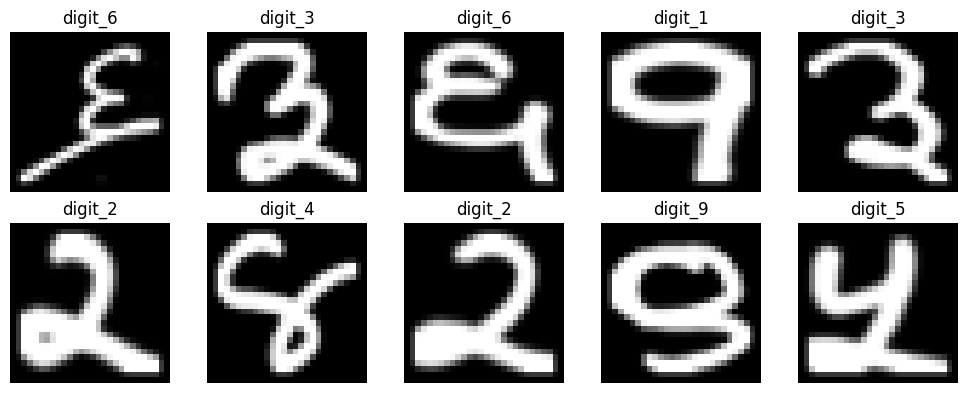

In [7]:
# Visualize a few clean images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(str(y_train[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Add noise and visualize data


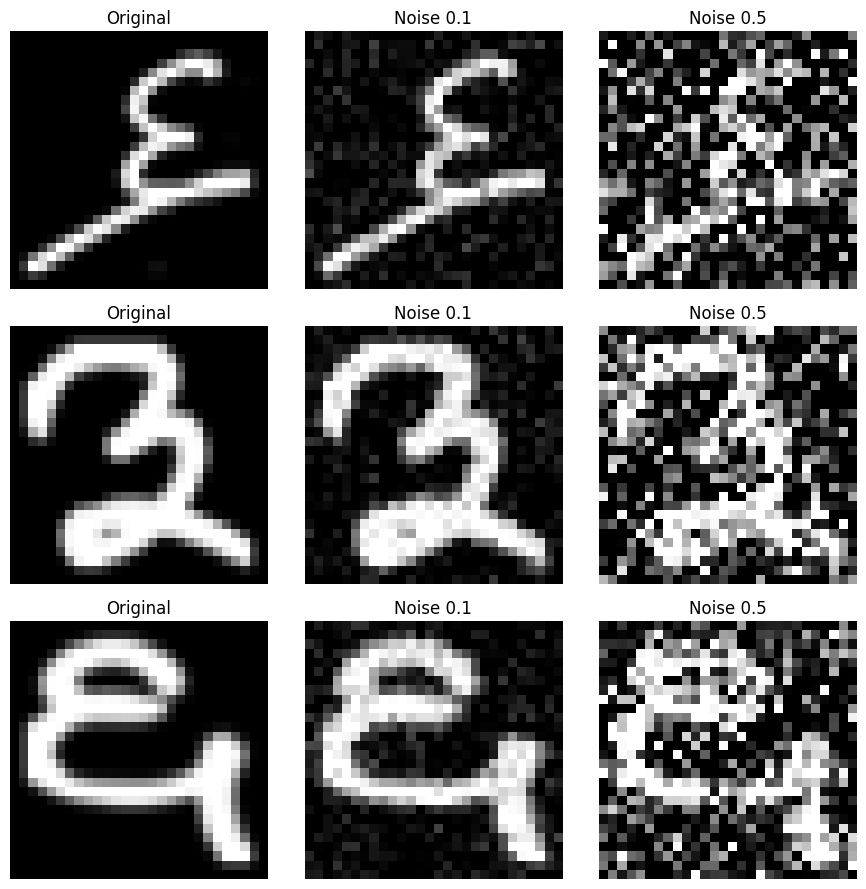

In [8]:
# Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)

x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0.0, 1.0)
x_train_noisy_high = np.clip(x_train_noisy_high, 0.0, 1.0)
x_test_noisy_low = np.clip(x_test_noisy_low, 0.0, 1.0)
x_test_noisy_high = np.clip(x_test_noisy_high, 0.0, 1.0)

# Visualize in a 3 x 3 grid
n = 3
plt.figure(figsize=(9, 9))

for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap="gray")
    plt.title("Noise 0.1")
    plt.axis("off")

    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap="gray")
    plt.title("Noise 0.5")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Build the Convolutional Denoising Autoencoder Model

In [9]:
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2), padding="same")(x)
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    encoded = MaxPooling2D((2, 2), padding="same", name="encoded")(x)
    return input_img, encoded

def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    """
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoded")(x)
    return decoded

def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder.
    """
    input_img, encoded_output = build_encoder(input_shape=x_train.shape[1:])
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss="binary_crossentropy")
    return autoencoder

In [10]:
# Compile the model
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Autoencoder

In [11]:
# Train with noisy input and clean target
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 56s 402ms/step - loss: 0.3091 - val_loss: 0.2242
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 54s 404ms/step - loss: 0.2141 - val_loss: 0.2083
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 78s 379ms/step - loss: 0.2036 - val_loss: 0.2008
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 82s 379ms/step - loss: 0.1981 - val_loss: 0.1963
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 53s 401ms/step - loss: 0.1944 - val_loss: 0.1930
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 78s 373ms/step - loss: 0.1918 - val_loss: 0.1906
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 53s 400ms/step - loss: 0.1900 - val_loss: 0.1891
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 51s 380ms/step - loss: 0.1886 - val_loss: 0.1878
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 50s 377ms/step - loss: 0.1875 - val_loss: 0.1868
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 83s 383ms/step - loss: 0.1865 - val_loss: 0.1858


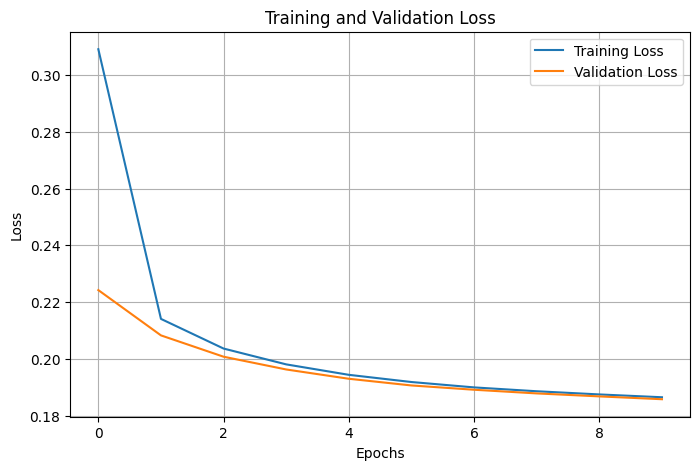

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 6. Evaluate the Autoencoder

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


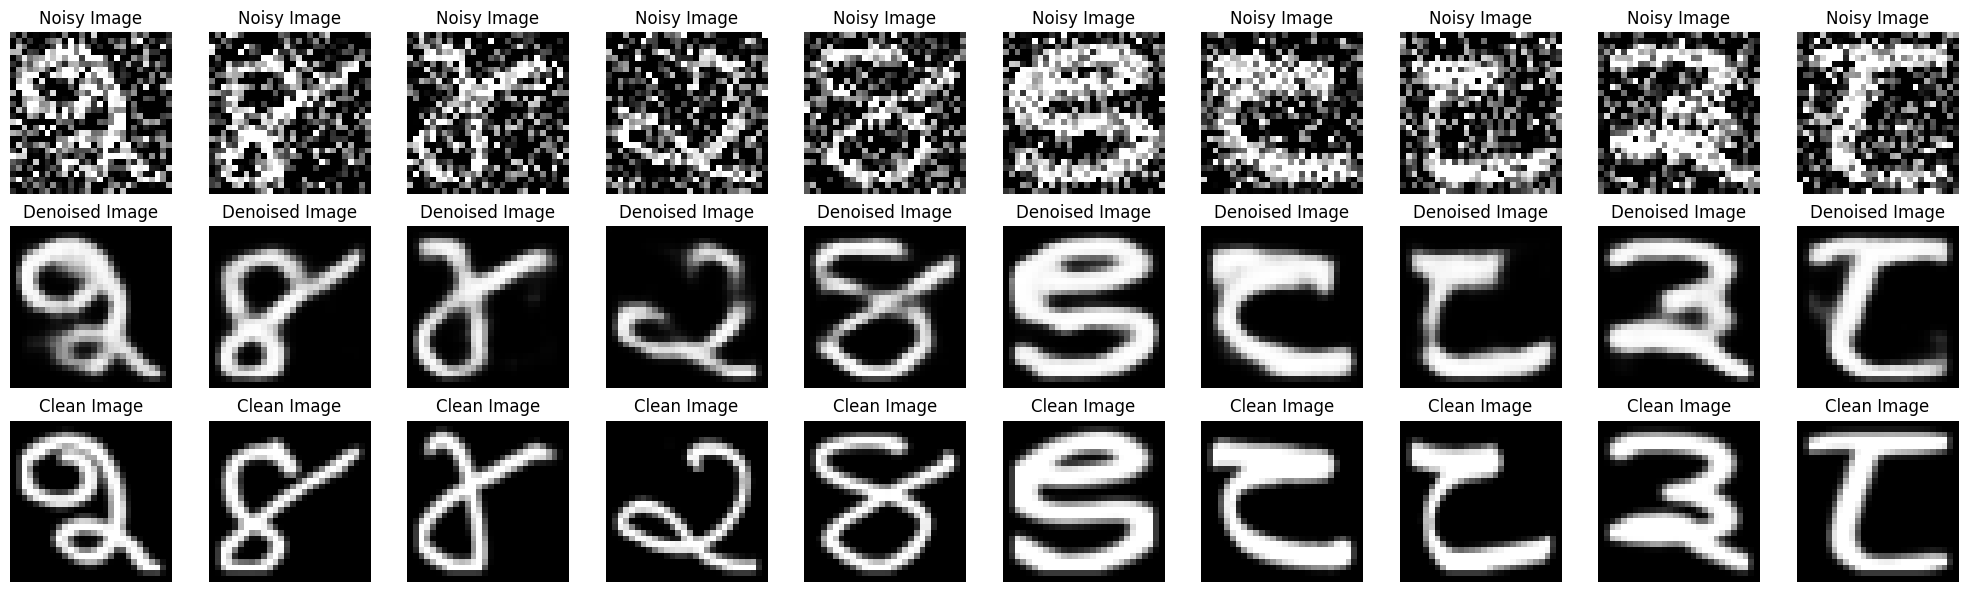

In [13]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap="gray")
        plt.title("Noisy Image")
        plt.axis("off")

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
        plt.title("Denoised Image")
        plt.axis("off")

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap="gray")
        plt.title("Clean Image")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

## 7. Simple experiment

In [14]:
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(16, (3, 3), activation="relu", padding="same")(input_img)
    x = MaxPooling2D((2, 2), padding="same")(x)
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    encoded = MaxPooling2D((2, 2), padding="same", name="encoded")(x)
    return input_img, encoded

def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.
    """
    x = Conv2D(32, (3, 3), activation="relu", padding="same")(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoded")(x)
    return decoded

def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder.
    """
    input_img, encoded_output = build_encoder(input_shape=x_train.shape[1:])
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss="binary_crossentropy")
    return autoencoder

In [15]:
# Compile the model
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,121 (129.38 KB)

 Trainable params: 33,121 (129.38 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train with noisy input and clean target
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=5,
    batch_size=64,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/5
266/266 ━━━━━━━━━━━━━━━━━━━━ 52s 184ms/step - loss: 0.2837 - val_loss: 0.2091
Epoch 2/5
266/266 ━━━━━━━━━━━━━━━━━━━━ 49s 185ms/step - loss: 0.2037 - val_loss: 0.1976
Epoch 3/5
266/266 ━━━━━━━━━━━━━━━━━━━━ 50s 189ms/step - loss: 0.1960 - val_loss: 0.1929
Epoch 4/5
266/266 ━━━━━━━━━━━━━━━━━━━━ 81s 184ms/step - loss: 0.1923 - val_loss: 0.1902
Epoch 5/5
266/266 ━━━━━━━━━━━━━━━━━━━━ 49s 183ms/step - loss: 0.1899 - val_loss: 0.1884


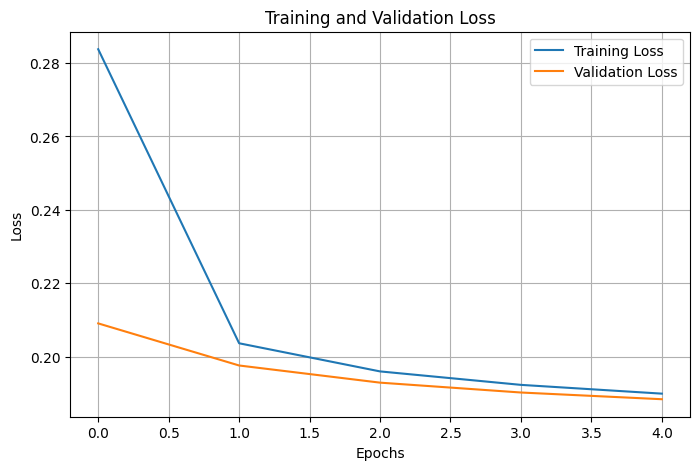

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


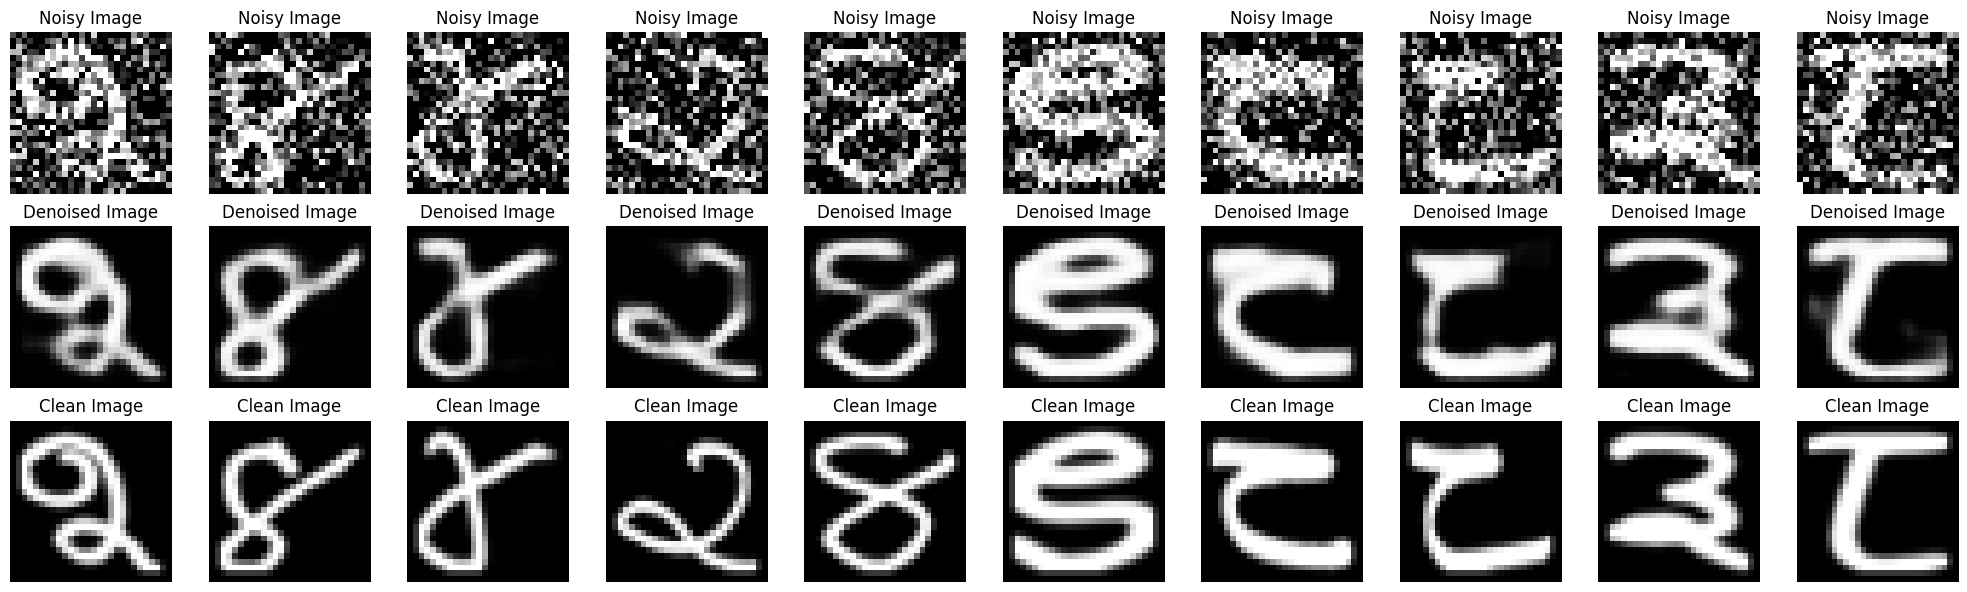

In [18]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap="gray")
        plt.title("Noisy Image")
        plt.axis("off")

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
        plt.title("Denoised Image")
        plt.axis("off")

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap="gray")
        plt.title("Clean Image")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_images(x_test_noisy_high, denoised_images, x_test, n=10)